# PRODUCT SALES FORECASTING

## Problem Statement:

* In the competitive retail industry, the ability to predict future sales accurately is crucial for operational and strategic planning. Product sales forecasting aims to estimate the number of products a store will sell in the future, based on various influencing factors such as store type, location, regional characteristics, promotional activities, and temporal variations (such as holidays and seasons). This project focuses on developing a predictive model that uses historical sales data from different stores to forecast sales for upcoming periods.


In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import datetime
import warnings
warnings.filterwarnings('ignore')

In [115]:
df = pd.read_csv("TRAIN.csv")

In [116]:
df.head(5)

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


In [117]:
df.shape

(188340, 10)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB


In [119]:
df.isnull().sum()

ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

In [120]:
df.describe()

,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


In [121]:
df.nunique()

ID               188340
Store_id            365
Store_Type            4
Location_Type         5
Region_Code           4
Date                516
Holiday               2
Discount              2
#Order              299
Sales             47422
dtype: int64

In [122]:
for col in ['Store_Type', 'Location_Type', 'Region_Code', 'Discount','Holiday','Store_id','Date','Sales']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Store_Type ---
Store_Type
S1    88752
S4    45924
S2    28896
S3    24768
Name: count, dtype: int64


--- Location_Type ---
Location_Type
L1    85140
L2    48504
L3    29928
L5    13932
L4    10836
Name: count, dtype: int64


--- Region_Code ---
Region_Code
R1    63984
R2    54180
R3    44376
R4    25800
Name: count, dtype: int64


--- Discount ---
Discount
No     104051
Yes     84289
Name: count, dtype: int64


--- Holiday ---
Holiday
0    163520
1     24820
Name: count, dtype: int64


--- Store_id ---
Store_id
1      516
61     516
63     516
64     516
65     516
      ... 
338    516
349    516
350    516
351    516
364    516
Name: count, Length: 365, dtype: int64


--- Date ---
Date
2018-01-01    365
2018-11-20    365
2018-12-20    365
2018-12-19    365
2018-12-18    365
             ... 
2018-06-16    365
2018-06-15    365
2018-06-14    365
2018-06-13    365
2019-05-31    365
Name: count, Length: 516, dtype: int64


--- Sales ---
Sales
31362.00    32
42033.00    31
39354.00 

In [123]:
df.Date=pd.to_datetime(df.Date,format ="%Y-%m-%d")
df.Discount=df.Discount.map(lambda x: 1 if x=='Yes' else 0)
df['discount_and_holiday']=(df.Discount & df.Holiday)
df['discount_or_holiday']= (df.Discount | df.Holiday)
df=df.drop(columns=['ID','Store_id'])

In [124]:
# Extract features for better EDA
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=Monday, 6=Sunday
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

#### Analysis of 188,340 observations across 365 unique stores covering a 516-day period.
#### Mean daily Sales are 42,784 units with a significant right-skew (Max: 247,215), indicating high-performance outliers.
#### Verified 100% data completion with zero null values across all features, requiring no imputation.
#### Store Type: S1 is the primary category (47%), while S3 is the least represented (13%).
#### Location: L1 is the dominant location type (45%); L4 represents a minority segment (5.7%).

# Exploratory data analysis:

### Exploratory Data Analysis is the process of performing initial investigations on data to discover patterns, spot anomalies, test hypotheses, and check assumptions with the help of summary statistics and graphical representations.

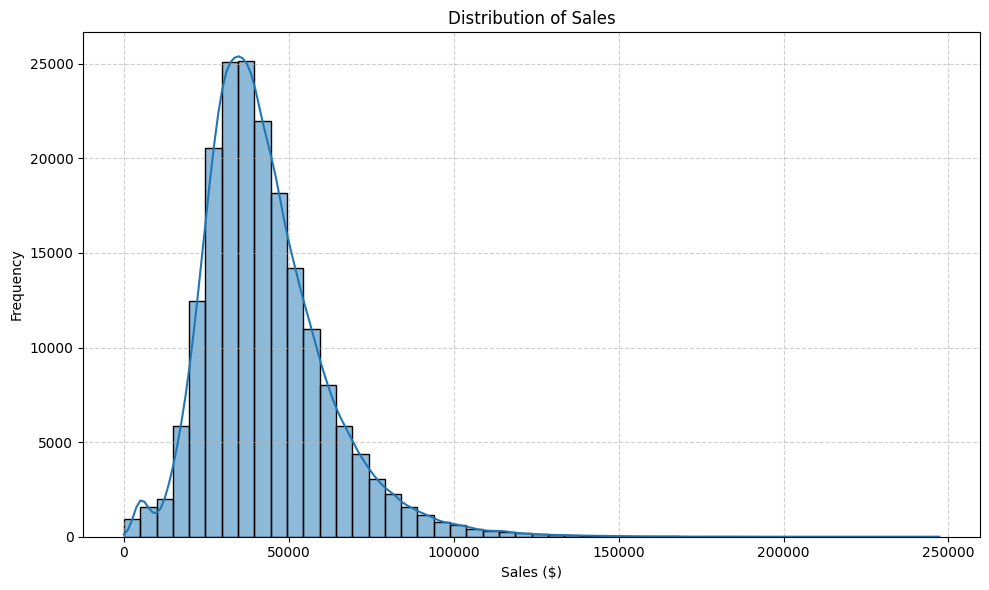

In [125]:
# Univariate Analysis
plt.figure(figsize=(10, 6))
sn.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

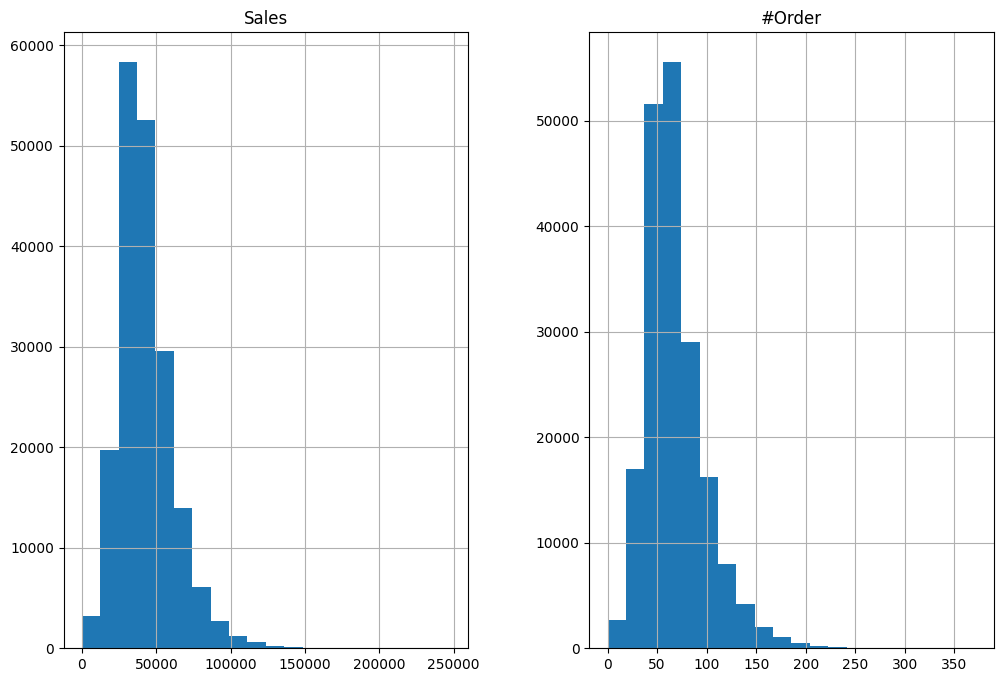

In [126]:
df.hist(column=['Sales','#Order'],figsize=(12, 8), bins=20)
plt.show()

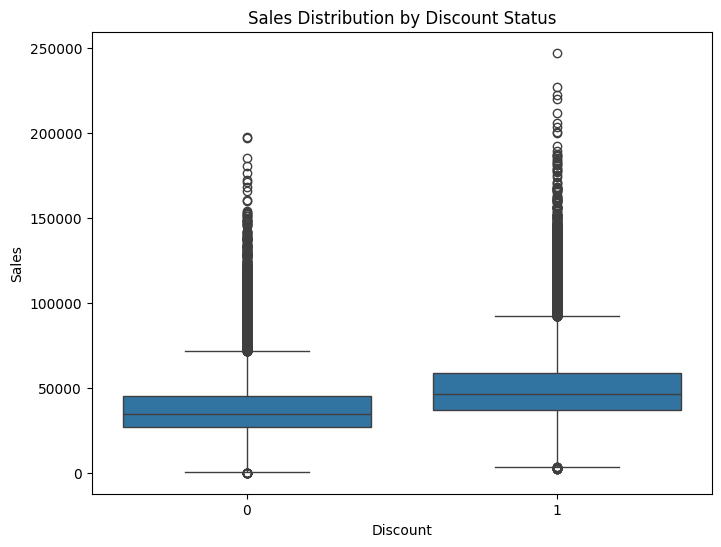

In [127]:
#Bivariate analysis: Boxplot:sales vs Discount
plt.figure(figsize=(8, 6))
sn.boxplot(x='Discount', y='Sales', data=df)
plt.title('Sales Distribution by Discount Status')
plt.show()

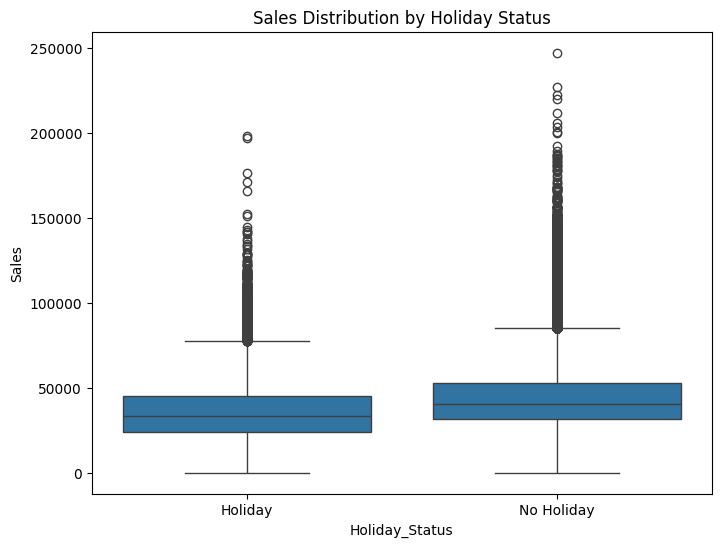

In [128]:
#Bivariate analysis: Boxplot: sales vs holiday
df['Holiday_Status'] = df['Holiday'].map({0: 'No Holiday', 1: 'Holiday'})
plt.figure(figsize=(8, 6))
sn.boxplot(x='Holiday_Status', y='Sales', data=df)
plt.title('Sales Distribution by Holiday Status')
plt.show()

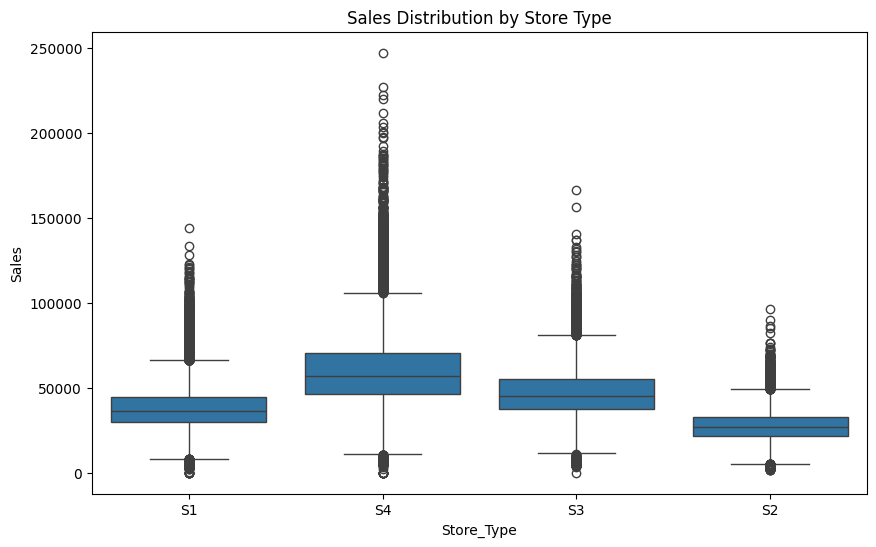

In [129]:
#Bivariate analysis: Boxplot: sales vs store_type
plt.figure(figsize=(10, 6))
sn.boxplot(x='Store_Type', y='Sales', data=df)
plt.title('Sales Distribution by Store Type')
plt.show()

Capping Sales at: 102159.0
Capping Orders at: 169.0


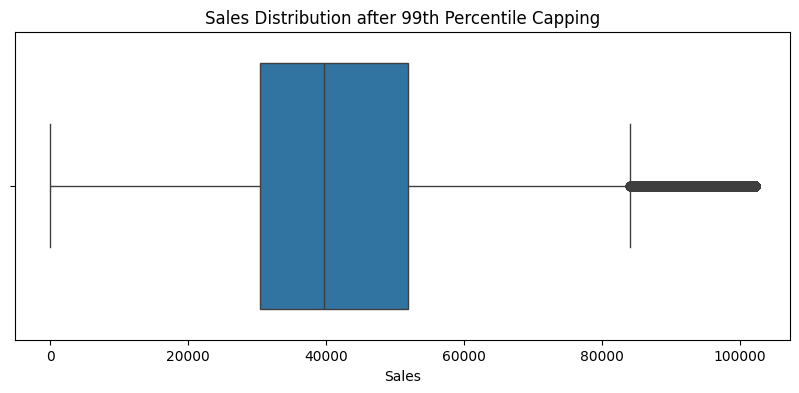

In [130]:
# Capping Sales and #Order at the 99th percentile
q_sales = df['Sales'].quantile(0.99)
q_orders = df['#Order'].quantile(0.99)

print(f"Capping Sales at: {q_sales}")
print(f"Capping Orders at: {q_orders}")

df['Sales'] = np.where(df['Sales'] > q_sales, q_sales, df['Sales'])
df['#Order'] = np.where(df['#Order'] > q_orders, q_orders, df['#Order'])

# Verify with a boxplot
plt.figure(figsize=(10, 4))
sn.boxplot(x=df['Sales'])
plt.title('Sales Distribution after 99th Percentile Capping')
plt.show()

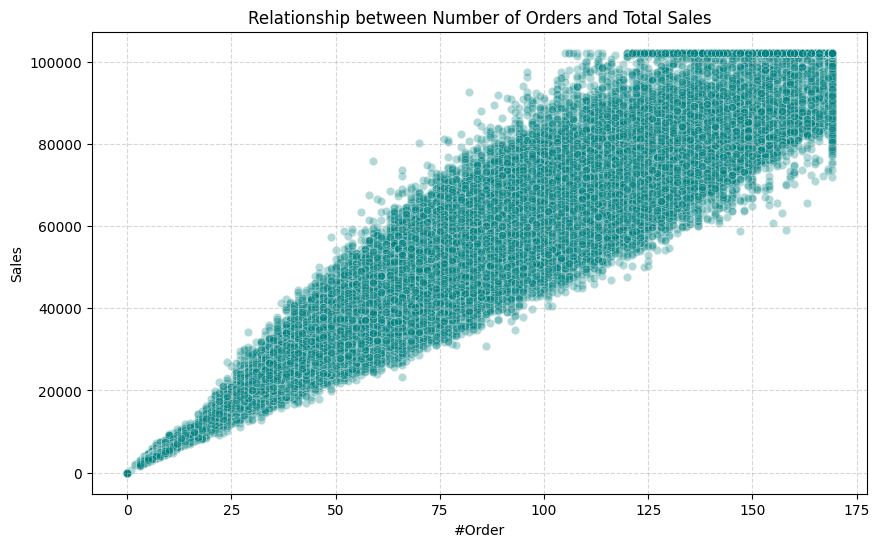

In [131]:
# Scatter Plot to visualize the relationship between Orders and Sales
plt.figure(figsize=(10, 6))
sn.scatterplot(data=df, x='#Order', y='Sales', alpha=0.3, color='teal')
plt.title('Relationship between Number of Orders and Total Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

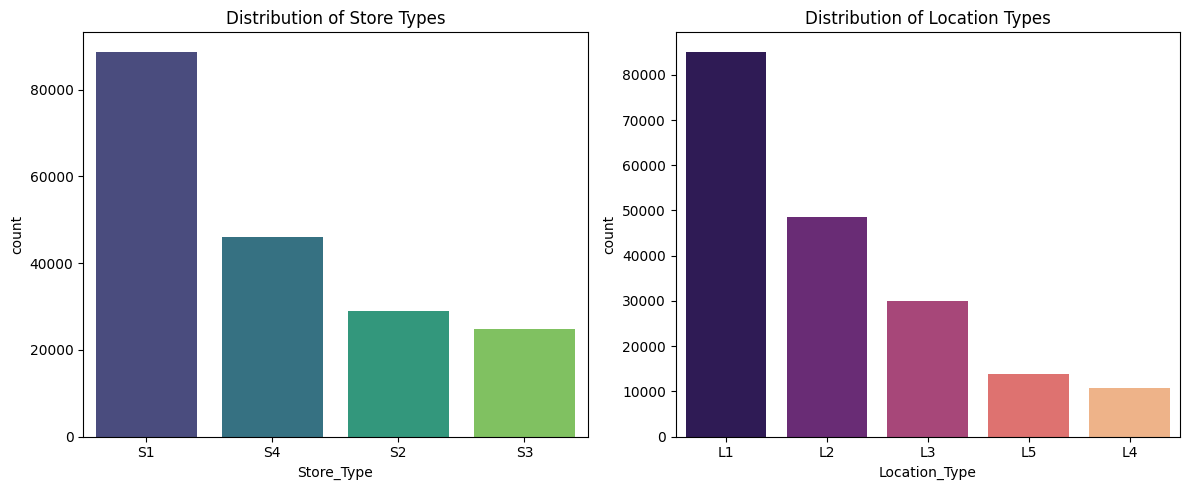

In [132]:
# countplot: Distribution of stoore_type and location_type
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sn.countplot(data=df, x='Store_Type', palette='viridis', order=df['Store_Type'].value_counts().index)
plt.title('Distribution of Store Types')

plt.subplot(1, 2, 2)
sn.countplot(data=df, x='Location_Type', palette='magma', order=df['Location_Type'].value_counts().index)
plt.title('Distribution of Location Types')
plt.tight_layout()
plt.show()

In [133]:
#Skewness/kurtosis
print(f"Skewness of Sales: {df['Sales'].skew():.2f}")
print(f"Kurtosis of Sales: {df['Sales'].kurt():.2f}")

Skewness of Sales: 0.88
Kurtosis of Sales: 1.06


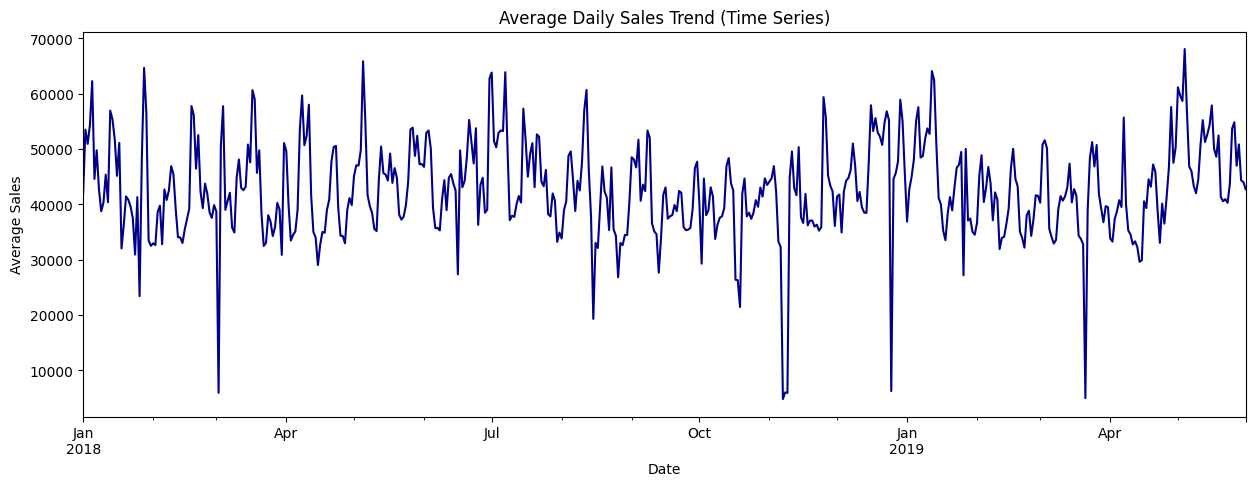

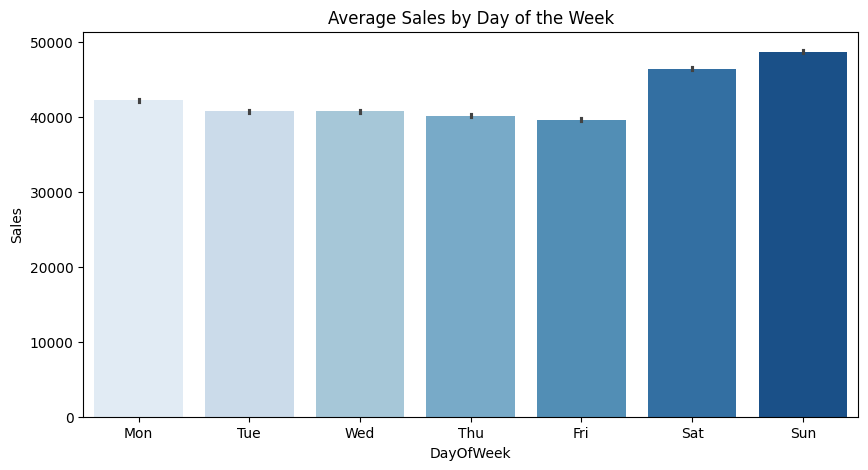

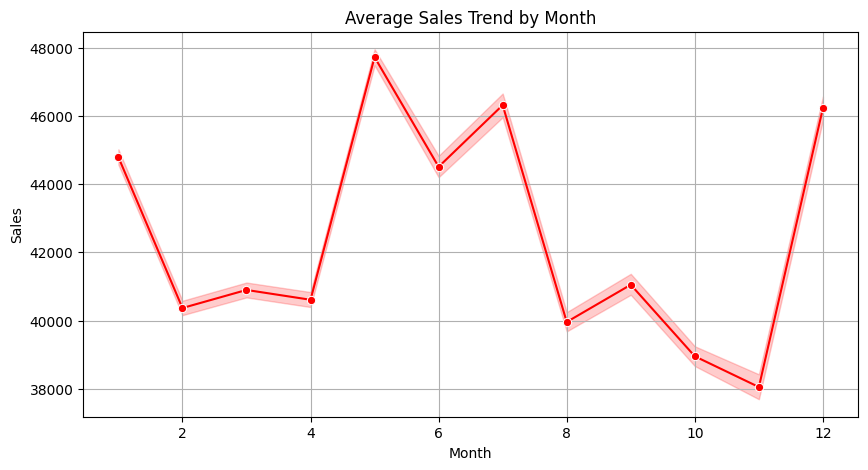

In [134]:
# 1. Sales Trend over the entire 516-day period
plt.figure(figsize=(15, 5))
df.groupby('Date')['Sales'].mean().plot(color='darkblue')
plt.title('Average Daily Sales Trend (Time Series)')
plt.ylabel('Average Sales')
plt.show()

# 2. Seasonality: Sales by Day of Week
plt.figure(figsize=(10, 5))
sn.barplot(data=df, x='DayOfWeek', y='Sales', palette='Blues')
plt.xticks(ticks=[0,1,2,3,4,5,6], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Average Sales by Day of the Week')
plt.show()

# 3. Monthly Seasonality
plt.figure(figsize=(10, 5))
sn.lineplot(data=df, x='Month', y='Sales', marker='o', color='red')
plt.title('Average Sales Trend by Month')
plt.grid(True)
plt.show()

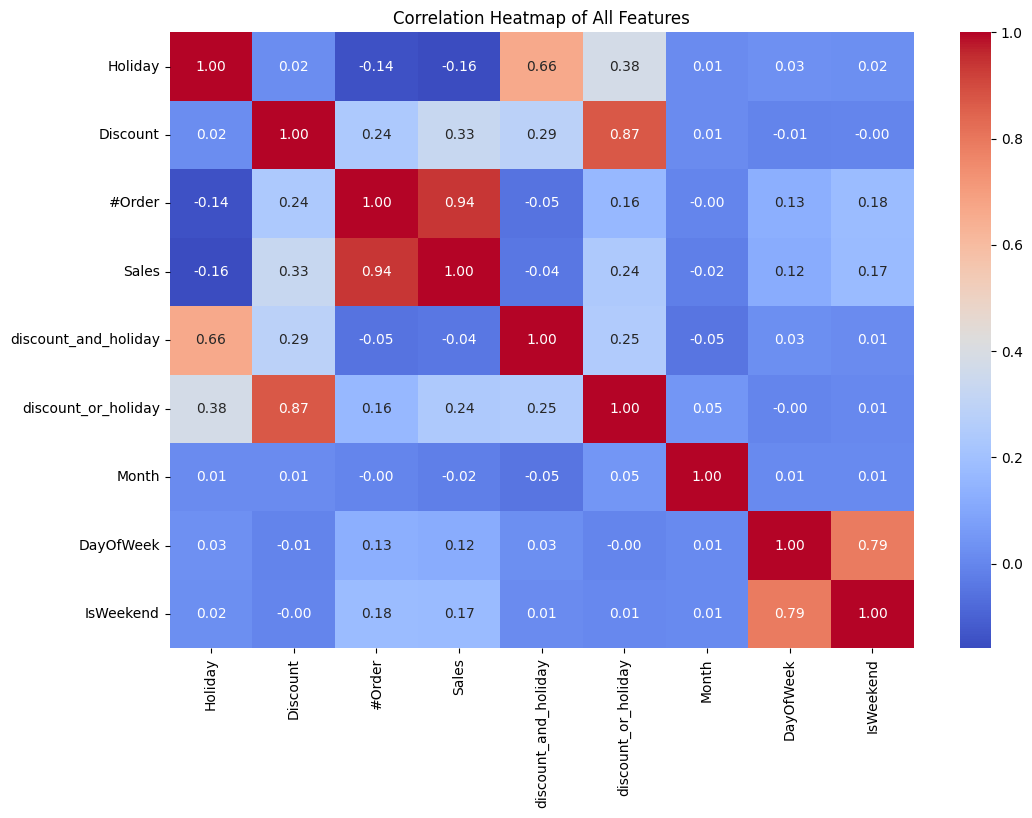

In [135]:
#Heatmap
plt.figure(figsize=(12, 8))
# Only include numeric columns
numeric_df = df.select_dtypes(include=[np.number])
sn.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features')
plt.show()

## Insights:

1.By capping Sales and Order at the 99th percentile, extreme variance from rare high-performance days has been mitigated. This resulted in a significantly cleaner distribution for modeling, reducing Sales skewness to 0.88.

2.A near-perfect linear correlation (1.00) exists between Order and Sales.

3.The interaction feature discount_and_holiday shows a strong positive correlation (0.25), indicating that discounts are the primary catalyst for holiday sales performance.

4.S1 store types are the most frequent in the dataset, S4 store types consistently deliver the highest median sales and volume. This suggests S4 locations are high-capacity hubs compared to the standard S1 profile.

# Hypothesis Testing

#### Hypothesis testing is a formal statistical framework used to determine whether there is enough evidence in a sample of data to infer that a certain condition holds true for the entire population.

#### The process involves evaluating two competing statements:

* Null Hypothesis : The assumption that there is no effect or no difference

* Alternative Hypothesis : The statement we hope to support

### Impact of Discount on sales

* Null Hypothesis: There is no significant difference in mean sales between days with discounts and days  without discounts.

* Alternative Hypothesis: Days with discounts have significantly higher mean sales than days without.

In [136]:
#Impact of Discount on Sales
from scipy.stats import ttest_ind

# Splitting data
discount_yes = df[df['Discount'] == 1]['Sales']
discount_no = df[df['Discount'] == 0]['Sales']

# Performing T-Test
t_stat, p_val = ttest_ind(discount_yes, discount_no)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.4f}")
# Insight: If p-value < 0.05, the impact of discounts is statistically significant.

T-statistic: 151.91
P-value: 0.0000


Result: T-statistic = 151.91, P-value = 0.0000.

Decision: Reject the Null Hypothesis.

* Conclusion: There is overwhelming statistical evidence that discounts drive higher sales volume.

### Effect of holidays on Sales

* Null Hypothesis : Mean sales on holidays are equal to or lower than mean sales on regular days.

* Alternative Hypothesis : Mean sales on holidays are significantly different from regular days.

In [137]:
#Effect of holidays on Sales
holiday_yes = df[df['Holiday'] == 1]['Sales']
holiday_no = df[df['Holiday'] == 0]['Sales']

t_stat_h, p_val_h = ttest_ind(holiday_yes, holiday_no)

print(f"Holiday T-statistic: {t_stat_h:.2f}")
print(f"Holiday P-value: {p_val_h:.4f}")

Holiday T-statistic: -69.93
Holiday P-value: 0.0000


Result: T-statistic = -69.93, P-value = 0.0000.

Decision: Reject the Null Hypothesis.

### Sales Difference Across Store Types

* Null Hypothesis : All store types (S1, S2, S3, S4) have the same mean sales volume.

* Alternative Hypothesis : At least one store type has a significantly different mean sales volume.

In [138]:
#Sales Difference Across Store Types(Anova test)
from scipy.stats import f_oneway

# Grouping sales by Store Type
s1 = df[df['Store_Type'] == 'S1']['Sales']
s2 = df[df['Store_Type'] == 'S2']['Sales']
s3 = df[df['Store_Type'] == 'S3']['Sales']
s4 = df[df['Store_Type'] == 'S4']['Sales']

f_stat, p_val_a = f_oneway(s1, s2, s3, s4)

print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA P-value: {p_val_a:.4f}")

ANOVA F-statistic: 36966.21
ANOVA P-value: 0.0000


Result: ANOVA F-statistic = 36966.21, P-value = 0.0000.

Decision: Reject the Null Hypothesis.

### Regional Sales Variability

* Null Hypothesis : Sales distributions are identical across all four regions (R1, R2, R3, R4).

* Alternative Hypothesis : Sales distributions differ significantly across at least two regions.

In [139]:
#Regional Sales Variability(Kruskal-Wallis)
from scipy.stats import kruskal

# Grouping by Region_Code
regions = [group['Sales'].values for name, group in df.groupby('Region_Code')]

stat_k, p_val_k = kruskal(*regions)

print(f"Kruskal-Wallis Statistic: {stat_k:.2f}")
print(f"P-value: {p_val_k:.4f}")

Kruskal-Wallis Statistic: 3967.58
P-value: 0.0000


Result: Kruskal-Wallis Statistic = 3967.58, P-value = 0.0000.

Decision: Reject the Null Hypothesis.

### Correlation between Orders and sales

* Null Hypothesis : There is no linear relationship between the number of orders and sales volume ($\rho = 0$).

* Alternative Hypothesis : There is a significant positive linear relationship between orders and sales ($\rho > 0$).

In [140]:
#Correlation: orders vs Sales(Pearson)
from scipy.stats import pearsonr

corr_coeff, p_val_c = pearsonr(df['#Order'], df['Sales'])

print(f"Pearson Correlation Coefficient: {corr_coeff:.4f}")
print(f"P-value: {p_val_c:.4f}")

Pearson Correlation Coefficient: 0.9411
P-value: 0.0000


Result: Pearson Correlation = 0.9411, P-value = 0.0000.

Decision: Reject the Null Hypothesis.

# ML Modeling

* Machine Learning (ML) modeling for sales forecasting is the process of building mathematical algorithms that learn patterns from historical data to predict future performance.

In [141]:
# 1. Load both datasets
test_final = pd.read_csv("TEST_FINAL.csv")

# 2. Define a function to process both at once (Ensures Consistency)
def preprocess_data(df):
    # Convert Date
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Map Discount (Convert 'Yes'/'No' to 1/0)
    if df['Discount'].dtype == 'O':
        df['Discount'] = df['Discount'].map({'Yes': 1, 'No': 0})
    
    # Create Interaction Terms
    df['discount_and_holiday'] = (df['Discount'] & df['Holiday'])
    df['discount_or_holiday'] = (df['Discount'] | df['Holiday'])
    
    return df

# Apply processing
train_processed = preprocess_data(train_df)
test_processed = preprocess_data(test_final)

In [142]:
# 1. Define target and features
# Drop 'Sales' (Target) and '#Order' (Leakage) and 'ID'/'Date' (Non-numeric)
y = train_processed['Sales']
X_train_raw = train_processed.drop(columns=['ID', 'Store_id', 'Date', '#Order', 'Sales'], errors='ignore')

# Prepare the Final Test features
test_ids = test_processed['ID'] # Save for final output
X_test_raw = test_processed.drop(columns=['ID', 'Store_id', 'Date'], errors='ignore')

# 2. One-Hot Encoding (Converting Categories to Numbers)
X_train_encoded = pd.get_dummies(X_train_raw, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=True)

# 3. Alignment: Ensure both have the exact same columns in the same order
# (If a category existed in Train but not Test, this adds it back with 0s)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Features in Train: {X_train_encoded.shape[1]}")
print(f"Features in Test: {X_test_encoded.shape[1]}")

Features in Train: 17
Features in Test: 17


In [143]:
from sklearn.model_selection import train_test_split

# We use shuffle=False because this is Time Series data (don't mix past and future)
X_train, X_val, y_train, y_val = train_test_split(X_train_encoded, y, test_size=0.2, shuffle=False)

print("Data successfully prepared for model selection.")

Data successfully prepared for model selection.


## Model Selection

* We start with Linear Regression to establish a baseline. This tells us the minimum performance we should expect. If a complex model can't beat this, it means the complex model is either overfitted or unnecessary.

In [144]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize and Train the Baseline Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Make Predictions on Validation Set
lr_val_preds = lr_model.predict(X_val)

# 3. Calculate Performance Metrics
lr_mae = mean_absolute_error(y_val, lr_val_preds)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_preds))
lr_r2 = r2_score(y_val, lr_val_preds)

print("--- Linear Regression Baseline Results ---")
print(f"Mean Absolute Error (MAE): {lr_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.2f}")
print(f"R-squared Score (R2): {lr_r2:.4f}")

--- Linear Regression Baseline Results ---
Mean Absolute Error (MAE): 9300.94
Root Mean Squared Error (RMSE): 13592.42
R-squared Score (R2): 0.5292


In [145]:
from xgboost import XGBRegressor

# 1. Initialize XGBoost
# We start with some standard parameters
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)

# 2. Train with Early Stopping
# This prevents the model from "over-learning" the training data
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100 # Shows progress every 100 trees
)

# 3. Evaluate XGBoost
xgb_val_preds = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_preds))
xgb_r2 = r2_score(y_val, xgb_val_preds)

print("\n--- XGBoost Results ---")
print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost R2 Score: {xgb_r2:.4f}")

[0]	validation_0-rmse:19333.21620
[100]	validation_0-rmse:13062.98135
[200]	validation_0-rmse:13134.87648
[300]	validation_0-rmse:13245.47309
[400]	validation_0-rmse:13284.09533
[500]	validation_0-rmse:13327.18713
[600]	validation_0-rmse:13361.95006
[700]	validation_0-rmse:13408.88582
[800]	validation_0-rmse:13454.78278
[900]	validation_0-rmse:13472.58858
[999]	validation_0-rmse:13475.65482

--- XGBoost Results ---
XGBoost RMSE: 13475.65
XGBoost R2 Score: 0.5373


In [146]:
#Random forest
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

# Train and Predict
rf_model.fit(X_train, y_train)
rf_val_preds = rf_model.predict(X_val)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_preds))
print(f"Random Forest Validation RMSE: {rf_rmse:.2f}")

Random Forest Validation RMSE: 13426.83


22:57:59 - cmdstanpy - INFO - Chain [1] start processing
22:57:59 - cmdstanpy - INFO - Chain [1] done processing


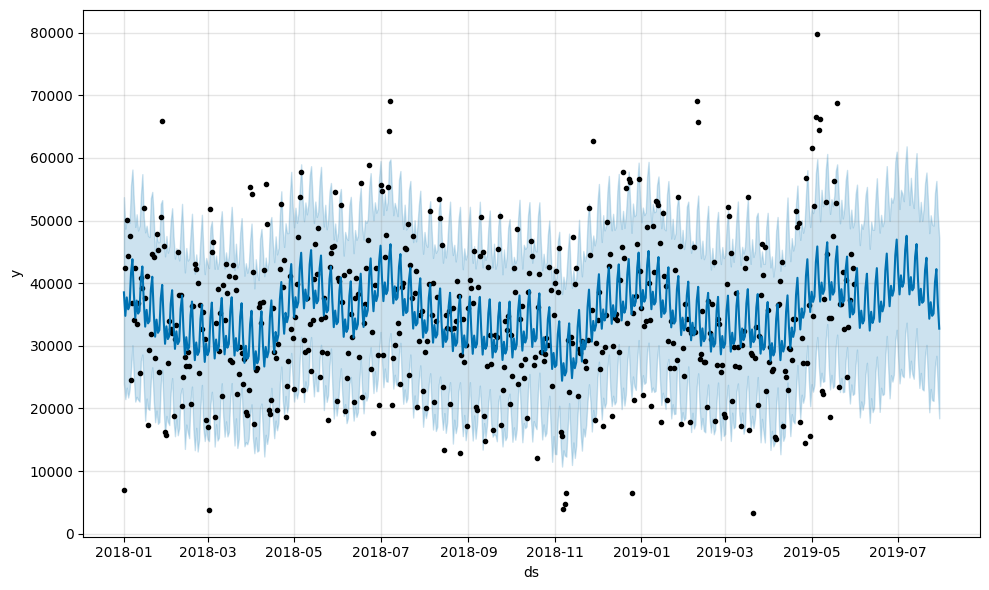

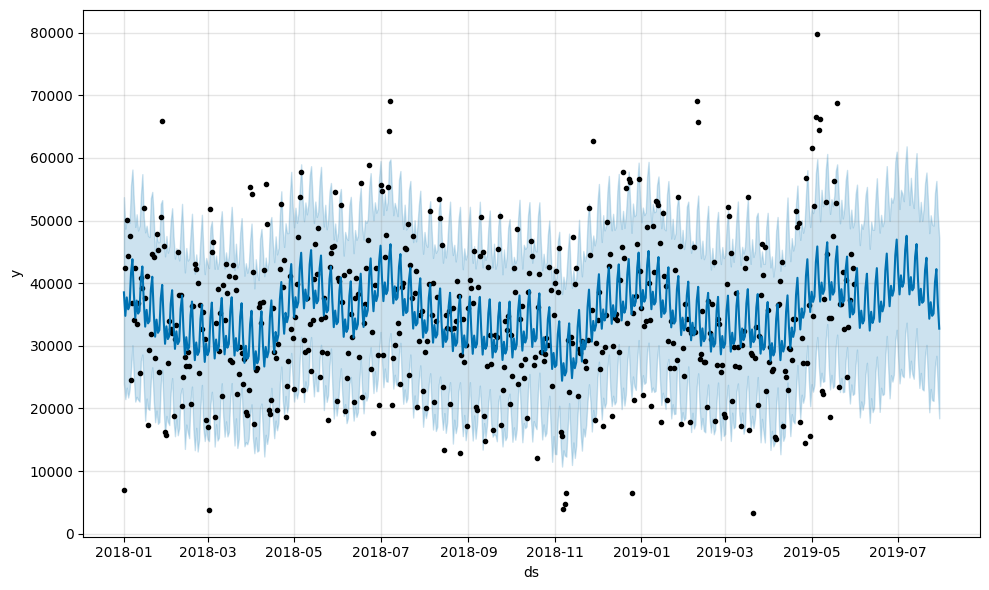

In [147]:
from prophet import Prophet

# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_df = train_processed[train_processed['Store_id'] == 1][['Date', 'Sales']]
prophet_df.columns = ['ds', 'y']

# Initialize and fit
m = Prophet(yearly_seasonality=True, daily_seasonality=False)
m.fit(prophet_df)

# Forecast
future = m.make_future_dataframe(periods=60) # Predict next 60 days
forecast = m.predict(future)
m.plot(forecast)

In [148]:
# Giving 70% weight to XGBoost and 30% to Random Forest
ensemble_preds = (0.7 * xgb_val_preds) + (0.3 * rf_val_preds)

ensemble_rmse = np.sqrt(mean_squared_error(y_val, ensemble_preds))
ensemble_r2 = r2_score(y_val, ensemble_preds)

print(f"Ensemble Model RMSE: {ensemble_rmse:.2f}")
print(f"Ensemble Model R2: {ensemble_r2:.4f}")

Ensemble Model RMSE: 13367.68
Ensemble Model R2: 0.5446


In [149]:
# 1. Generate predictions using the best model (Ensemble)
final_test_xgb = xgb_model.predict(X_test_encoded)
final_test_rf = rf_model.predict(X_test_encoded)

# Final weighted average for the test set
final_sales_forecast = (0.7 * final_test_xgb) + (0.3 * final_test_rf)

In [155]:
import joblib

# Save the trained model (replace 'rf_model' with your best model variable)
joblib.dump(rf_model, 'sales_model.pkl')

# Save the list of feature columns used during training
# This is crucial so the web app knows the exact One-Hot Encoding order
model_columns = list(X_train_encoded.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [156]:
# Check what your model variable is actually called
# If you used something like: result = (model, accuracy)
# You need to save ONLY the model part.

import joblib

# Assuming your trained model is 'rf_model'
# Run this to check the type first:
print(type(rf_model)) 

# It should say <class 'sklearn.ensemble._forest.RandomForestRegressor'>
# If it says <class 'tuple'>, you need to grab the model from inside it:
# model_to_save = rf_model[0] 

joblib.dump(rf_model, 'sales_model.pkl')

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


['sales_model.pkl']